<a href="https://colab.research.google.com/github/bemakerorg/AIoT_Book_II_RF/blob/main/AIOT_RF_Book_ES_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELLA 1 - Verifica versioni librerie
import tensorflow as tf  # Framework per machine learning
import numpy as np  # Libreria per calcoli numerici
import PIL  # Libreria per manipolazione immagini
import sklearn  # Libreria per machine learning
import matplotlib  # Libreria per grafici
import os  # Libreria per operazioni su file system

print("TensorFlow:", tf.__version__)  # Verifica versione TensorFlow
print("NumPy:", np.__version__)  # Verifica versione NumPy
print("Pillow:", PIL.__version__)  # Verifica versione Pillow
print("Scikit-learn:", sklearn.__version__)  # Verifica versione Scikit-learn
print("Matplotlib:", matplotlib.__version__)  # Verifica versione Matplotlib

# 💾 Salva versioni in requirements.txt per riproducibilità
with open("requirements.txt", "w") as f:  # Apri file per scrittura
    f.write(f"tensorflow=={tf.__version__}\n")  # Salva versione TensorFlow
    f.write(f"numpy=={np.__version__}\n")  # Salva versione NumPy
    f.write(f"Pillow=={PIL.__version__}\n")  # Salva versione Pillow
    f.write(f"scikit-learn=={sklearn.__version__}\n")  # Salva versione Scikit-learn
    f.write(f"matplotlib=={matplotlib.__version__}\n")  # Salva versione Matplotlib

TensorFlow: 2.18.0
NumPy: 2.0.2
Pillow: 11.2.1
Scikit-learn: 1.6.1
Matplotlib: 3.10.0


In [2]:
# CELLA 2 - Download dataset da Roboflow con struttura folder
!pip install roboflow --quiet  # Installa Roboflow in modalità silenziosa

from getpass import getpass  # Importa per input sicuro password
from roboflow import Roboflow  # Importa SDK Roboflow

# 🔑 Richiedi API Key in modo sicuro
api_key = getpass("Inserisci la tua Roboflow PRIVATE API Key: ")  # Input sicuro API key
rf = Roboflow(api_key=api_key)  # Inizializza client Roboflow

# 📥 Download dataset "face_vww" in formato folder
face_project = rf.workspace().project("face_vww")  # Connetti al progetto face
face_version = face_project.version(1)  # Seleziona versione 1
face_dataset = face_version.download("folder")  # Scarica in formato folder

# 📥 Download dataset "no_face" in formato folder
no_face_project = rf.workspace().project("no_face_vww")  # Connetti al progetto no_face
no_face_version = no_face_project.version(1)  # Seleziona versione 1
no_face_dataset = no_face_version.download("folder")  # Scarica in formato folder

print(f"\n📂 Dataset face_vww scaricato in: {face_dataset.location}")  # Stampa percorso face
print(f"\n📂 Dataset no_face scaricato in: {no_face_dataset.location}")  # Stampa percorso no_face

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.1 MB/s eta 0:00:00
Inserisci la tua Roboflow PRIVATE API Key: ··········
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Face_VWW-1 in folder:: 100%|██████████| 1272/1272 [00:00<00:00, 5462.08it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to No_Face_VWW-1 in folder:: 100%|██████████| 1302/1302 [00:00<00:00, 6227.85it/s]


📂 Dataset face_vww scaricato in: /content/Face_VWW-1

📂 Dataset no_face scaricato in: /content/No_Face_VWW-1


In [3]:
# CELLA 3 - Caricamento immagini

def count_images_in_folder(folder):
    """Conta file immagine in una cartella specifica"""
    if not os.path.exists(folder):  # Verifica esistenza cartella
        return 0  # Ritorna 0 se cartella non esiste
    return len([f for f in os.listdir(folder)  # Conta file
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))])  # Solo immagini

# Definisci percorsi corretti basati sulla struttura reale
face_base = face_dataset.location  # Percorso base dataset face
no_face_base = no_face_dataset.location  # Percorso base dataset no_face

print(f"📂 Percorso base Face: {face_base}")  # Stampa percorso face
print(f"📂 Percorso base No_Face: {no_face_base}")  # Stampa percorso no_face

# Definisci percorsi specifici per ogni split e classe
face_paths = {  # Dizionario percorsi face
    "train": os.path.join(face_base, "train", "Face"),  # Percorso train face
    "valid": os.path.join(face_base, "valid", "Face"),  # Percorso valid face
    "test": os.path.join(face_base, "test", "Face")     # Percorso test face
}

no_face_paths = {  # Dizionario percorsi no_face
    "train": os.path.join(no_face_base, "train", "No_Face"),  # Percorso train no_face
    "valid": os.path.join(no_face_base, "valid", "No_Face"),  # Percorso valid no_face
    "test": os.path.join(no_face_base, "test", "No_Face")     # Percorso test no_face
}

# Verifica esistenza cartelle e conta immagini
print("\n🔍 Verifica struttura cartelle e conteggio immagini:")  # Intestazione verifica

face_totals = {}  # Dizionario totali face
no_face_totals = {}  # Dizionario totali no_face

for split in ["train", "valid", "test"]:  # Per ogni split
    # Conta immagini face
    face_dir = face_paths[split]  # Ottieni percorso face
    face_count = count_images_in_folder(face_dir)  # Conta immagini face
    face_totals[split] = face_count  # Salva conteggio

    # Conta immagini no_face
    no_face_dir = no_face_paths[split]  # Ottieni percorso no_face
    no_face_count = count_images_in_folder(no_face_dir)  # Conta immagini no_face
    no_face_totals[split] = no_face_count  # Salva conteggio

# 📊 Calcola totali generali
total_face = sum(face_totals.values())  # Totale face
total_no_face = sum(no_face_totals.values())  # Totale no_face
total_general = total_face + total_no_face  # Totale generale

print(f"\n" + "="*50)  # Separatore
print("📋 RIEPILOGO FINALE DATASET")  # Intestazione finale
print("="*50)  # Separatore
print(f"👤 Totale Face: {total_face} immagini")  # Totale face
print(f"🚫 Totale No_Face: {total_no_face} immagini")  # Totale no_face
print(f"📦 Totale generale: {total_general} immagini")  # Totale generale

# 🎯 Verifica bilanciamento
if total_face > 0 and total_no_face > 0:  # Se entrambi hanno immagini
    ratio = total_face / total_no_face  # Calcola rapporto
    print(f"⚖️ Rapporto Face/No_Face: {ratio:.2f}")  # Stampa rapporto

    if 0.8 <= ratio <= 1.2:  # Se bilanciato
        print("✅ Dataset ben bilanciato")  # Messaggio bilanciato
    else:
        print("⚠️ Dataset sbilanciato")  # Avviso sbilanciamento

📂 Percorso base Face: /content/Face_VWW-1
📂 Percorso base No_Face: /content/No_Face_VWW-1

🔍 Verifica struttura cartelle e conteggio immagini:

📋 RIEPILOGO FINALE DATASET
👤 Totale Face: 1264 immagini
🚫 Totale No_Face: 1294 immagini
📦 Totale generale: 2558 immagini
⚖️ Rapporto Face/No_Face: 0.98
✅ Dataset ben bilanciato


In [4]:
# CELLA 4 - Preparazione dataset combinato FACE + NO_FACE
#--------------------------------------------------------------------
from collections import Counter

def list_image_paths_and_labels(directory, label):
    """Funzione per elencare percorsi immagini e assegnare etichette"""
    if not os.path.exists(directory):
        print(f"⚠️ Directory non trovata: {directory}")
        return []

    files = [f for f in os.listdir(directory) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    return [(os.path.join(directory, fname), label) for fname in files]

# ✅ Etichette: face=1, no_face=0 (ENTRAMBE LE CLASSI)
datasets = {}
counts_per_split = {}
class_names = ["no_face", "face"]             # ⭐ ORDINE CORRETTO: indice 0=no_face, indice 1=face

for split in ["train", "valid", "test"]:
    # USA I PERCORSI CORRETTI DALLA CELLA 3
    face_dir = face_paths[split]  # Usa percorsi definiti in CELLA 3
    no_face_dir = no_face_paths[split]  # Usa percorsi definiti in CELLA 3

    # Carica ENTRAMBE le classi
    face_data = list_image_paths_and_labels(face_dir, 1)  # Face = etichetta 1
    no_face_data = list_image_paths_and_labels(no_face_dir, 0)  # No_face = etichetta 0

    # BILANCIAMENTO FORZATO - Prendi stesso numero per entrambe le classi
    min_samples = min(len(face_data), len(no_face_data))
    if min_samples > 0:
        face_data = face_data[:min_samples]  # Limita face
        no_face_data = no_face_data[:min_samples]  # Limita no_face

    # Combina entrambe le classi
    combined_data = face_data + no_face_data

    if not combined_data:
        print(f"❌ Nessuna immagine trovata per {split}")
        paths, labels = [], []
    else:
        paths, labels = zip(*combined_data)

    # Salva conteggi per monitoraggio
    label_counts = Counter(labels)
    counts_per_split[split] = label_counts

    # Crea dataset TensorFlow con SHUFFLE FORTE
    if paths:
        # Converti in liste e mescola
        paths_list = list(paths)
        labels_list = list(labels)

        # Mescola i dati
        import random
        combined_shuffled = list(zip(paths_list, labels_list))
        random.shuffle(combined_shuffled)
        paths_shuffled, labels_shuffled = zip(*combined_shuffled)

        ds = tf.data.Dataset.from_tensor_slices((list(paths_shuffled), list(labels_shuffled)))
        ds = ds.map(lambda path, label: (
            tf.image.convert_image_dtype(tf.image.resize(
                tf.image.decode_jpeg(tf.io.read_file(path), channels=3), [224, 224]
            ), tf.float32),
            tf.cast(label, tf.int32)  # IMPORTANTE: cast a int32
        ), num_parallel_calls=tf.data.AUTOTUNE)

        # SHUFFLE MULTIPLO per evitare bias
        ds = ds.shuffle(buffer_size=len(paths_shuffled), reshuffle_each_iteration=True)
        ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
        datasets[split] = ds
    else:
        datasets[split] = None

# Assegna i dataset
train_ds = datasets.get("train")
val_ds = datasets.get("valid")
test_ds = datasets.get("test")

# VERIFICA CRITICA - Controlla distribuzione reale
print(f"\n🔍 Verifica distribuzione finale:")
for split in ["train", "valid", "test"]:
    if split in counts_per_split and counts_per_split[split]:
        counts = counts_per_split[split]
        total = sum(counts.values())
        face_pct = (counts.get(1, 0) / total) * 100 if total > 0 else 0     # Percentuale face
        no_face_pct = (counts.get(0, 0) / total) * 100 if total > 0 else 0  # Percentuale no_face

        print(f"\n🔹 {split.upper()}:")
        print(f"   - Face: {counts.get(1, 0)} ({face_pct:.1f}%)")
        print(f"   - No_face: {counts.get(0, 0)} ({no_face_pct:.1f}%)")

        # AVVISO SE SBILANCIATO
        if abs(face_pct - no_face_pct) > 10:
            print(f"   ⚠️ DATASET SBILANCIATO! Differenza: {abs(face_pct - no_face_pct):.1f}%")

# CONTROLLO FINALE
if train_ds is None or val_ds is None:
    print("\n❌ ERRORE: Dataset mancanti!")
    raise ValueError("Dataset mancanti - impossibile procedere")
else:
    print("\n✅ Dataset pronti per addestramento bilanciato!")


🔍 Verifica distribuzione finale:

🔹 TRAIN:
   - Face: 885 (50.0%)
   - No_face: 885 (50.0%)

🔹 VALID:
   - Face: 253 (50.0%)
   - No_face: 253 (50.0%)

🔹 TEST:
   - Face: 126 (50.0%)
   - No_face: 126 (50.0%)

✅ Dataset pronti per addestramento bilanciato!


In [5]:
# CELLA 5 - Configurazione del modello pre-addestrato

import tensorflow_hub as hub         # TensorFlow Hub: per utilizzare modelli pre-addestrati condivisi

# URL del modello MobileNetV2 senza testa (solo feature vector), ospitato su TensorFlow Hub.
module_handle = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
# Dimensione di input delle immagini. MobileNetV2 richiede immagini 224x224
IMAGE_SIZE = (224, 224)
# Dimensione del vettore di caratteristiche (feature vector) prodotto da MobileNetV2. È una rappresentazione numerica dell'immagine
FV_SIZE = 1280
num_classes = 2 # Numero di classi da classificare

# Carica il modulo da TF Hub
# Carica il modello pre-addestrato da TensorFlow Hub. feature_extractor sarà una funzione che prende un'immagine e restituisce un vettore di caratteristiche
feature_extractor = hub.load(module_handle)

# Definisci il modello Keras usando l'API funzionale
# Definisce l'input del modello Keras. Le immagini hanno dimensione (224, 224, 3), dove 3 sono i canali RGB.
inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))

# Crea un layer Lambda che applica la funzione feature_extractor all'input.
# L'uso di Lambda è utile per evitare errori quando si integra un modello TF Hub in un modello Keras.
feature_vector = tf.keras.layers.Lambda(
    lambda x: feature_extractor(x), output_shape=(FV_SIZE,), trainable=False
)(inputs)

# Aggiunge un layer denso (Dense) finale con num_classes neuroni e attivazione softmax, per ottenere una distribuzione di probabilità sulle classi.
dense_output = tf.keras.layers.Dense(num_classes, activation='softmax')(feature_vector)

# Definisci il modello completo specificando input e output
model = tf.keras.Model(inputs=inputs, outputs=dense_output)

# Stampa un riassunto della struttura del modello: layer, dimensioni in input/output e numero di parametri.
model.summary()

model.compile(                                  # Compila il modello specificando:
    optimizer='adam',                           # Ottimizzatore: adam, adatto alla maggior parte dei casi.
    loss='sparse_categorical_crossentropy',     # Funzione di perdita: sparse_categorical_crossentropy, usata per classificazione multiclasse con etichette intere (es. 0, 1)
    metrics=['accuracy']                        # Metriche: accuracy per valutare la performance.
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,562 (10.01 KB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# CELLA 6 - Addestramento
epochs = 15  # Numero massimo di epoche

history = model.fit(  # Avvia addestramento
    train_ds,  # Dataset di training
    validation_data=val_ds,  # Dataset di validazione
    epochs=epochs,  # Numero epoche
    verbose=1  # Stampa progresso
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.8706 - loss: 0.3345 - val_accuracy: 0.9526 - val_loss: 0.1095
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9628 - loss: 0.1088 - val_accuracy: 0.9644 - val_loss: 0.0871
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9685 - loss: 0.0851 - val_accuracy: 0.9625 - val_loss: 0.0790
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9691 - loss: 0.0664 - val_accuracy: 0.9684 - val_loss: 0.0697
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9728 - loss: 0.0585 - val_accuracy: 0.9723 - val_loss: 0.0625
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9858 - loss: 0.0440 - val_accuracy: 0.9684 - val_loss: 0.0586
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9837 - loss: 0.0406 - val_accuracy: 0.9802 - val_loss: 0.0581
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9869 - loss: 0.0446 - val_accuracy: 0.9783 - val_loss

In [7]:
# CELLA 7 - Salvataggio del Modello "specializzato"
import pathlib                                # pathlib per operazioni su percorsi di file
# Esportazione del modello in formato SavedModel
FACE_DETECTION_MODEL = 'saved_model/1'                     # Directory di destinazione
model.export(FACE_DETECTION_MODEL)                         # Esporta il modello in SavedModel compatibile TF

# Calcolo dell’occupazione di memoria del modello salvato
import os                                       #libreria per la gestione dei path di disco
def get_directory_size(FACE_DETECTION_MODEL):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(FACE_DETECTION_MODEL):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total_size += os.path.getsize(fp)
    #return total_size / (1024 * 1024)          # Dimensione in MB
    return total_size                           # Dimensione in Byte

file_size_savedmodel = get_directory_size(FACE_DETECTION_MODEL)
#print(f"Dimensione del modello SavedModel: {file_size_savedmodel:.2f} MB")
print(f"Dimensione del modello SavedModel: {file_size_savedmodel:.2f} Byte")

Saved artifact at 'saved_model/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137674120616208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674122469520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674118714512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674120513488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674120523856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674122477392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674118724304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674122469712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674122466640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674120525968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674120518480: 

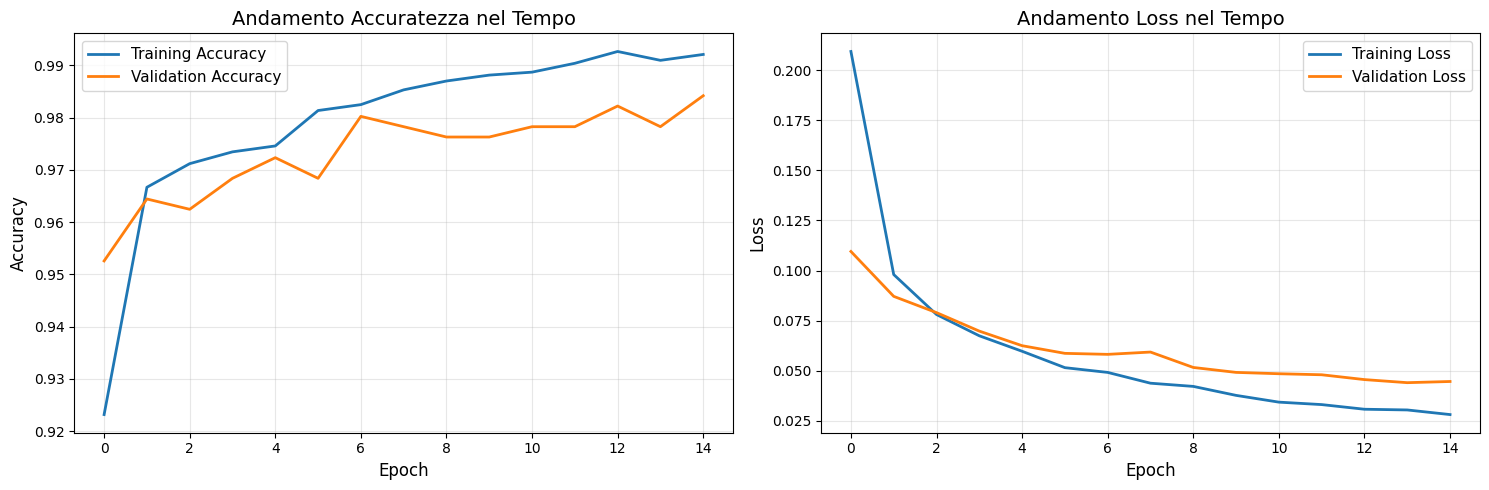


📊 Test Accuracy: 0.9802
📊 Test Loss: 0.0653


<Figure size 800x600 with 0 Axes>

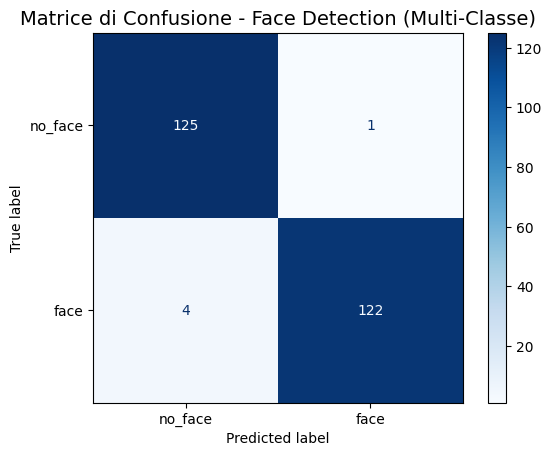


📋 Report di Classificazione:
              precision    recall  f1-score   support

     no_face       0.97      0.99      0.98       126
        face       0.99      0.97      0.98       126

    accuracy                           0.98       252
   macro avg       0.98      0.98      0.98       252
weighted avg       0.98      0.98      0.98       252



In [8]:
# CELLA 8 - Valutazione e matrici
import matplotlib.pyplot as plt  # Importa matplotlib per grafici
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay  # Importa metriche
import numpy as np  # Importa numpy

# 📈 Plot training history
acc = history.history['accuracy']  # Accuratezza training
val_acc = history.history['val_accuracy']  # Accuratezza validazione
loss = history.history['loss']  # Loss training
val_loss = history.history['val_loss']  # Loss validazione
epochs_range = range(len(acc))  # Range epoche

plt.figure(figsize=(15, 5))  # Imposta dimensioni figura
plt.subplot(1, 2, 1)  # Primo subplot
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)  # Plot accuratezza training
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)  # Plot accuratezza validazione
plt.title('Andamento Accuratezza nel Tempo', fontsize=14)  # Titolo
plt.xlabel('Epoch', fontsize=12)  # Label asse x
plt.ylabel('Accuracy', fontsize=12)  # Label asse y
plt.legend(fontsize=11)  # Legenda
plt.grid(True, alpha=0.3)  # Griglia

plt.subplot(1, 2, 2)  # Secondo subplot
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)  # Plot loss training
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)  # Plot loss validazione
plt.title('Andamento Loss nel Tempo', fontsize=14)  # Titolo
plt.xlabel('Epoch', fontsize=12)  # Label asse x
plt.ylabel('Loss', fontsize=12)  # Label asse y
plt.legend(fontsize=11)  # Legenda
plt.grid(True, alpha=0.3)  # Griglia

plt.tight_layout()  # Layout ottimizzato
plt.show()  # Mostra grafici

# 🧪 Test set evaluation
test_loss, test_acc = model.evaluate(test_ds, verbose=0)  # Valuta su test set
print(f"\n📊 Test Accuracy: {test_acc:.4f}")  # Stampa accuratezza test
print(f"📊 Test Loss: {test_loss:.4f}")  # Stampa loss test

# 📋 Matrice di confusione
y_true, y_pred = [], []  # Liste per etichette vere e predette
for images, labels in test_ds:  # Itera su batch test
    predictions = model.predict(images, verbose=0)  # Ottieni predizioni softmax [batch, 2]
    y_true.extend(labels.numpy())  # Aggiungi etichette vere (0 o 1)
    y_pred.extend(np.argmax(predictions, axis=1))  # ⭐ ARGMAX per classe con probabilità maggiore

cm = confusion_matrix(y_true, y_pred)  # Calcola matrice confusione
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)  # Crea display
plt.figure(figsize=(8, 6))  # Imposta dimensioni
disp.plot(cmap='Blues', values_format='d')  # Plot matrice con colori
plt.title('Matrice di Confusione - Face Detection (Multi-Classe)', fontsize=14)  # Titolo
plt.show()  # Mostra matrice

# 📝 Report classificazione
print("\n📋 Report di Classificazione:")  # Intestazione
print(classification_report(y_true, y_pred, target_names=class_names))  # Stampa report completo

In [9]:
# CELLA 9 - Conversione Modello in TFLite

print("Conversione Modello Base in TFLite...")  # Intestazione

# CONVERSIONE MODELLO BASE in TFLite (senza quantizzazione)
converter_tflite = tf.lite.TFLiteConverter.from_keras_model(model)  # Convertitore
converter_tflite.optimizations = [tf.lite.Optimize.DEFAULT]  # Abilita ottimizzazioni
tflite_model = converter_tflite.convert()  # Conversione

# Specifica la directory per salvare il modello TFLite
tflite_models_dir = pathlib.Path("/tmp/")  # Usa una directory temporanea

# Salva il modello convertito in un file chiamato "model1.tflite", "model2.tflite", oppure "model3.tflite"
tflite_model_file = tflite_models_dir / 'model_tflite.tflite'   # Nome del file per il modello TFLite da modificare in model2 e model3
tflite_model_file.write_bytes(tflite_model)               # Scrive il contenuto del modello TFLite nel file

Conversione Modello Base in TFLite...
Saved artifact at '/tmp/tmpamwmuqec'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137674120616208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674122469520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674118714512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674120513488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674120523856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674122477392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674118724304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674122469712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674122466640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137674120525968: TensorSpec(shape=(), dtype=tf

2501312

In [10]:
# CELLA 10 - FASE DI RIDUZIONE TFLITE QUANTIZZAZIONE INT8

# Configurazione del converter TFLite per il SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model(FACE_DETECTION_MODEL)  # Crea il converter
converter.experimental_enable_resource_variables = True          # Fold delle variabili in costanti

# Creazione di un convertitore TFLite dal modello salvato
converter = tf.lite.TFLiteConverter.from_saved_model(FACE_DETECTION_MODEL)

# Abilita le ottimizzazioni predefinite per ridurre le dimensioni e migliorare l'efficienza
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Decommenta questa linea per Model 2 e Model 3

# Generazione di un dataset rappresentativo per la quantizzazione intera (da usare per il Model 3)
# Decommenta queste 5 linee sotto per ottenere il Model 3
def representative_data_gen():
  for input_value, _ in train_ds.take(100):  # Usa 100 batch di dati di TRAIN per rappresentare la distribuzione
    yield [input_value]
converter.representative_dataset = representative_data_gen  # Assegna il dataset rappresentativo
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8] # Specifica di supportare operazioni quantizzate (INT8)

# Conversione del modello in formato TFLite
tflite_model = converter.convert()

# Specifica la directory per salvare il modello TFLite
tflite_models_dir = pathlib.Path("/tmp/")  # Usa una directory temporanea

# Salva il modello convertito in un file chiamato "model1.tflite", "model2.tflite", oppure "model3.tflite"
tflite_model_file = tflite_models_dir / 'model_int.tflite'   # Nome del file per il modello TFLite da modificare in model2 e model3
tflite_model_file.write_bytes(tflite_model)               # Scrive il contenuto del modello TFLite nel file

2704696

In [11]:
# CELLA 11 - Test con Validazione del modello esaminato

from tqdm import tqdm  # Libreria per visualizzare barre di progresso
tflite_model_file = '/tmp/model_int.tflite'  # Specifica il percorso ed il nome del file con cui è stato salvato il modello TFLite
interpreter = tf.lite.Interpreter(model_path=tflite_model_file)  # Carica il modello TFLite e Istanzia un interprete TFLite per eseguire l'inferenza.
interpreter.allocate_tensors()  # Alloca i tensori necessari per l'inferenza

input_details = interpreter.get_input_details()[0]  # Ottiene i dettagli del tensore di input
output_details = interpreter.get_output_details()[0]  # Ottiene i dettagli del tensore di output

predictions = []  # Array per salvare le predizioni
test_labels, test_imgs = [], []  # Array per etichette e immagini di test

# Get input quantization parameters if available
input_scale, input_zero_point = input_details['quantization'] if 'quantization' in input_details and input_details['quantization'] != (0.0, 0) else (1.0, 0)

# Iterate through the test_ds dataset batch by batch
for images, labels in tqdm(test_ds.take(100)):  # cycle through 100 batches from the test dataset
    # Iterate through each image in the batch
    for i in range(images.shape[0]):
        img = images[i]  # Get the individual image
        label = labels[i].numpy()  # Get the individual label

        # Preprocess and quantize the image to INT8 if necessary
        img = tf.expand_dims(img, 0)  # Add batch dimension

        if input_details['dtype'] == np.int8:
            # Quantize the image to INT8 based on the input details
            # Assuming input is in [0, 1] range (from dataset preparation)
            img = (img / input_scale + input_zero_point).astype(input_details['dtype'])
        elif input_details['dtype'] == np.uint8:
             img = (img / input_scale + input_zero_point).astype(input_details['dtype'])


        interpreter.set_tensor(input_details['index'], img)  # Imposta il tensore di input con l'immagine singola
        interpreter.invoke()  # Esegue l'inferenza

        # Get the output tensor and dequantize if necessary
        output_data = interpreter.get_tensor(output_details['index'])
        if output_details['dtype'] == np.int8:
             scale, zero_point = output_details['quantization']
             output_data = (output_data.astype(np.float32) - zero_point) * scale # Dequantize

        predictions.append(output_data)  # Salva la predizione
        test_labels.append(label)  # Salva l'etichetta reale
        test_imgs.append(img)  # Salva l'immagine

# Nota: le iterazioni al secondo e quindi la velocità di esecuzione dell'inferenza dipende dal dispositivo su cui si fa girare il modello

score = 0  # Contatore per il numero di predizioni corrette

for item in range(len(predictions)):  # Itera su tutte le predizioni raccolte
  prediction = np.argmax(predictions[item])  # Seleziona l'indice con il valore più alto nella distribuzione di probabilità predetta e converte la predizione in una etichetta
  label = test_labels[item]  # Etichetta reale
  if prediction == label:  # Confronta predizione ed etichetta reale
    score += 1  # Incrementa il punteggio in caso di successo

print("Su " + str(len(predictions)) + " previsioni che ho ricevuto " + str(score) + " corretti")

100%|██████████| 8/8 [00:10<00:00,  1.28s/it]

Su 252 previsioni che ho ricevuto 249 corretti


INFERENZA CON MODELLO TFLITE QUANTIZZATO

📊 INFO MODELLO SELEZIONATO:
   - Percorso: /tmp/model_int.tflite
   - Quantizzazione output: Non applicata
   - Input Tensor Type: <class 'numpy.float32'>
   - Output Tensor Type: <class 'numpy.float32'>

📤 CARICA IMMAGINI PER TEST CON MODELLO QUANTIZZATO:


Saving 0004.png to 0004 (1).png
   🔧 Preprocessing FLOAT32: range [11.000, 255.000]

🔍 ANALISI OUTPUT TFLITE:
   ✅ Somma probabilità: 1.000000

📊 RISULTATI INFERENZA:
   ⏱️ Tempo inferenza: 20.05 ms
   🚫 Confidenza NO_FACE: 0.003906 (0.39%)
   👤 Confidenza FACE: 0.996094 (99.61%)
   🎯 Classe predetta: 1 (face)
   📏 Gap confidenze: 0.992188
   📈 Confidenza massima: 0.996094
   🤖 🟢 CITOFONO ATTIVATO - Volto rilevato!
   📞 [SISTEMA CITOFONO] Chiamata in corso...
   🔔 [NOTIFICA] Visitatore rilevato all'ingresso
   📧 [LOG] Face detection: 0.996 confidence


Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.


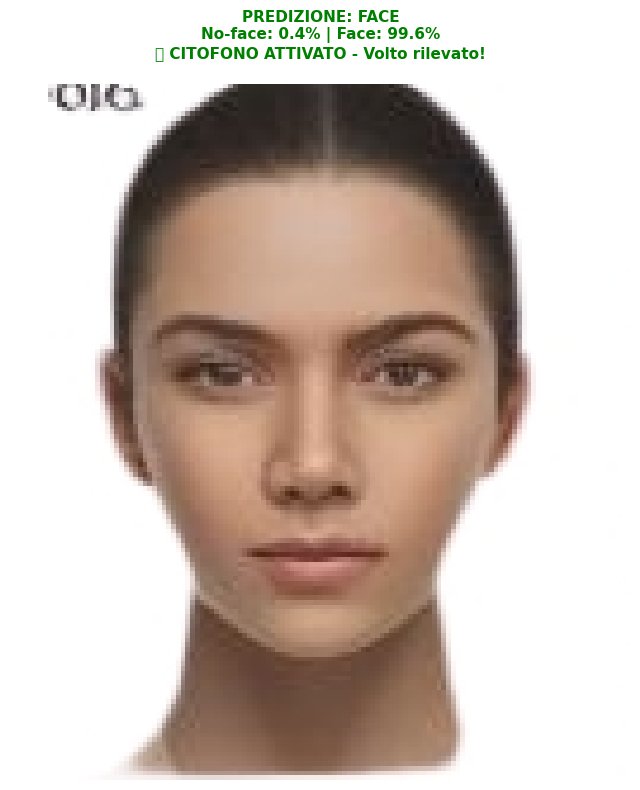


🎯 TEST TFLITE COMPLETATO - Modello pronto per produzione!


In [22]:
# CELLA 12 - Inferenza con modello quantizzato
from google.colab import files  # Importa per upload file
from tensorflow.keras.preprocessing import image  # Importa preprocessing immagini
import matplotlib.pyplot as plt  # Importa matplotlib
import time # Import time module for timing

print("INFERENZA CON MODELLO TFLITE QUANTIZZATO")  # Intestazione

# Seleziona modello ottimale FACE_DETECTION_MODEL
selected_model_path = '/tmp/model_int.tflite' # Seleziona modello ridotto con TFLite
#selected_model_path = '/tmp/model_tflite.tflite' # Seleziona modello ridotto con TFLite e Quantizzato INT8
# You might want to make this dynamic based on which model you want to test (model1, model2, or model3)
# For now, it's hardcoded to model_int.tflite

# Inizializza interprete con modello selezionato
interpreter = tf.lite.Interpreter(model_path=selected_model_path)  # Carica modello selezionato
interpreter.allocate_tensors()  # Alloca tensori

input_details = interpreter.get_input_details()  # Dettagli input
output_details = interpreter.get_output_details()  # Dettagli output

# Stampa info modello dettagliate
print(f"\n📊 INFO MODELLO SELEZIONATO:")  # Intestazione info
print(f"   - Percorso: {selected_model_path}")  # Percorso file

# Check input and output tensor types for quantization
input_dtype = input_details[0]['dtype']
output_dtype = output_details[0]['dtype']

if 'quantization' in output_details[0] and output_details[0]['quantization'][0] != 0:  # Se quantizzato
    scale = output_details[0]['quantization'][0]  # Scala
    zero_point = output_details[0]['quantization'][1]  # Zero point
    print(f"   - Quantizzazione output: scale={scale:.6f}, zero_point={zero_point}")  # Info quantizzazione
    is_quantized = True  # Flag quantizzazione
else:
    print(f"   - Quantizzazione output: Non applicata")  # Non quantizzato
    is_quantized = False  # Flag quantizzazione

print(f"   - Input Tensor Type: {input_dtype}")
print(f"   - Output Tensor Type: {output_dtype}")


def preprocess_img_tflite(path, input_details):
    """Preprocessing immagine CORRETTO per TFLite basato su CELLA 9"""
    # ⭐ CARICA IMMAGINE CON STESSO METODO DELLA CELLA 9
    img = image.load_img(path, target_size=(224, 224))  # Carica RGB automatico
    img_array = image.img_to_array(img)  # Converti a array [224, 224, 3]
    img_array = np.expand_dims(img_array, axis=0)  # Batch dimension [1, 224, 224, 3]

    # ⭐ PREPROCESSING IDENTICO AL TRAINING (Scaling to [0, 1])
    img_array_tf = tf.image.convert_image_dtype(img_array, tf.float32)  # [0, 255] -> [0, 1]
    img_array_normalized = img_array_tf.numpy()  # Converti a numpy

    # Then adapt to the TFLite model's input type based on input_details
    input_dtype = input_details['dtype']
    input_scale, input_zero_point = input_details['quantization'] if 'quantization' in input_details and input_details['quantization'] != (0.0, 0) else (1.0, 0)

    if input_dtype == np.int8:  # If input is INT8 quantized
        # Convert from [0,1] to the quantized range
        # The quantization formula is usually: quantized_value = round(float_value / scale + zero_point)
        # So, float_value = (quantized_value - zero_point) * scale
        # We need to do the inverse: quantized_value = float_value / scale + zero_point
        img_array_final = (img_array_normalized / input_scale + input_zero_point).astype(input_dtype)
        print(f"   🔧 Preprocessing INT8: range [{img_array_final.min()}, {img_array_final.max()}]")  # Debug
    elif input_dtype == np.uint8:  # If input is UINT8 quantized
         img_array_final = (img_array_normalized / input_scale + input_zero_point).astype(input_dtype)
         print(f"   🔧 Preprocessing UINT8: range [{img_array_final.min()}, {img_array_final.max()}]")  # Debug
    else:  # If input is float32
        img_array_final = img_array_normalized.astype(np.float32)  # Keep float32
        print(f"   🔧 Preprocessing FLOAT32: range [{img_array_final.min():.3f}, {img_array_final.max():.3f}]")  # Debug

    return img_array_final  # Return processed array

def analyze_tflite_output(output_raw, output_details):
    """Analizza output TFLite con gestione quantizzazione corretta"""
    print(f"\n🔍 ANALISI OUTPUT TFLITE:")  # Intestazione

    output_dtype = output_details['dtype']
    if output_dtype == np.int8 or output_dtype == np.uint8:  # If output is quantized
        # Dequantize the output
        scale, zero_point = output_details['quantization']
        dequantized = (output_raw.astype(np.float32) - zero_point) * scale  # Dequantize
        print(f"      - Valore dequantizzato: {dequantized}")  # Valore dequantizzato

        # ⭐ IMPORTANTE: The TFLite model output is [prob_no_face, prob_face]
        prob_no_face = float(dequantized[0][0])  # Probability no_face (index 0)
        prob_face = float(dequantized[0][1])     # Probability face (index 1)

    else:  # If output is float
        # ⭐ IMPORTANTE: The TFLite model output is [prob_no_face, prob_face]
        prob_no_face = float(output_raw[0][0])  # Probability no_face (index 0)
        prob_face = float(output_raw[0][1])     # Probability face (index 1)

    # Verify that probabilities sum to ~1 (softmax check)
    total_prob = prob_no_face + prob_face  # Sum
    print(f"   ✅ Somma probabilità: {total_prob:.6f}")  # Verifica softmax

    if abs(total_prob - 1.0) > 0.1:  # If sum is significantly different from 1
        print(f"   ⚠️ ATTENZIONE: Somma probabilità anomala!")  # Avviso

    return prob_no_face, prob_face  # Return probabilities


def simulate_citofono_activation(prob_face, prob_no_face, threshold_face=0.6, max_no_face=0.4, min_gap=0.2):
    """Simula attivazione citofono con logica sofisticata della CELLA 9"""
    confidence_gap = abs(prob_face - prob_no_face)  # Gap confidenze

    # SOPHISTICATED LOGIC: Multiple conditions for activation
    should_activate = (prob_face > threshold_face and           # High face confidence
                      prob_no_face < max_no_face and           # Low no_face confidence
                      confidence_gap > min_gap)                # Significant gap

    if should_activate:  # If should activate
        return "🟢 CITOFONO ATTIVATO - Volto rilevato!", True  # Activate
    else:
        return "🔴 Citofono in standby - Nessun volto", False  # Standby

# Upload images for testing
print(f"\n📤 CARICA IMMAGINI PER TEST CON MODELLO QUANTIZZATO:")  # Instructions
uploaded = files.upload()  # Upload files from user

# Perform inference on each uploaded image
results_tflite = []  # List of results
total_inference_time = 0  # Total time

for i, fname in enumerate(uploaded.keys(), 1):  # For each uploaded file
    # Preprocess image
    img_array = preprocess_img_tflite(fname, input_details[0])  # Preprocess

    # Perform inference with timing
    start_time = time.time()  # Start time
    interpreter.set_tensor(input_details[0]['index'], img_array)  # Set input
    interpreter.invoke()  # Perform inference
    inference_time = (time.time() - start_time) * 1000  # Time in ms
    total_inference_time += inference_time  # Accumulate time

    # Get output
    output_raw = interpreter.get_tensor(output_details[0]['index'])  # Raw output

    # Analyze output with quantization handling
    prob_no_face, prob_face = analyze_tflite_output(output_raw, output_details[0])  # Analyze

    # Determine predicted class
    predicted_class = 1 if prob_face > prob_no_face else 0  # 1=face, 0=no_face
    predicted_label = class_names[predicted_class]  # Class name

    # Calculate metrics
    confidence_gap = abs(prob_face - prob_no_face)  # Confidence gap
    max_confidence = max(prob_no_face, prob_face)  # Maximum confidence

    # Simulate intercom behavior with sophisticated logic
    activation_message, is_activated = simulate_citofono_activation(prob_face, prob_no_face)  # Simulate

    # 📊 Print detailed results
    print(f"\n📊 RISULTATI INFERENZA:")  # Header
    print(f"   ⏱️ Tempo inferenza: {inference_time:.2f} ms")  # Time
    print(f"   🚫 Confidenza NO_FACE: {prob_no_face:.6f} ({prob_no_face*100:.2f}%)")  # No_face
    print(f"   👤 Confidenza FACE: {prob_face:.6f} ({prob_face*100:.2f}%)")  # Face
    print(f"   🎯 Classe predetta: {predicted_class} ({predicted_label})")  # Class
    print(f"   📏 Gap confidenze: {confidence_gap:.6f}")  # Gap
    print(f"   📈 Confidenza massima: {max_confidence:.6f}")  # Max confidence
    print(f"   🤖 {activation_message}")  # Intercom status

    # Simulate full system
    if is_activated:  # If intercom activated
        print(f"   📞 [SISTEMA CITOFONO] Chiamata in corso...")  # Simulate call
        print(f"   🔔 [NOTIFICA] Visitatore rilevato all'ingresso")  # Simulate notification
        print(f"   📧 [LOG] Face detection: {prob_face:.3f} confidence")  # Log system

    # Save results
    results_tflite.append({
        'filename': fname,
        'prob_face': prob_face,
        'prob_no_face': prob_no_face,
        'predicted_class': predicted_class,
        'predicted_label': predicted_label,
        'inference_time': inference_time,
        'is_activated': is_activated,
        'confidence_gap': confidence_gap
    })

    # Display result
    plt.figure(figsize=(12, 8))  # Dimensions
    plt.imshow(image.load_img(fname))  # Show image

    # Detailed title with all info
    title_color = 'green' if is_activated else 'red'  # Color based on activation
    title_text = f"PREDIZIONE: {predicted_label.upper()}\n"  # Class
    title_text += f"No-face: {prob_no_face*100:.1f}% | Face: {prob_face*100:.1f}%\n"  # Confidences
    title_text += f"{activation_message}\n"  # Status

    plt.title(title_text, fontsize=11, color=title_color, weight='bold')  # Title
    plt.axis('off')  # Hide axes
    plt.tight_layout()  # Layout
    plt.show()  # Show

print(f"\n🎯 TEST TFLITE COMPLETATO - Modello pronto per produzione!")  # Final message